In [2]:
from model_functions import processing_predictingPipeline, evaluate_model_single_set
from utils import load_set
import pandas as pd
import numpy as np
import pickle

In [3]:
X_val, y_val = load_set('data/df_val_raw.csv')

In [4]:
def assign_rating(pd_value, thresholds, labels):
    """
    Pomocnicza funkcja mapująca PD na Rating.
    Zakłada, że thresholds to górne granice dla danego labela.
    """
    # Zabezpieczenie na wypadek, gdyby długości się nie zgadzały
    if len(thresholds) != len(labels)+1:
        return "Error: Length Mismatch"
    
    for thresh, label in zip(thresholds, labels):
        if pd_value <= thresh:
            return label
    
    # Jeśli PD jest wyższe niż najwyższy próg (najgorszy rating)
    return labels[-1]

def analyze_observations(model, X_data, binary_threshold, rating_thresholds, rating_labels, n_rows=None):
    """
    Analizuje obserwacje, przypisuje ratingi i kolory ryzyka.
    
    Args:
        model: wytrenowany model (calibrated)
        X_data: dane wejściowe (features)
        binary_threshold: próg odcięcia (cut-off) dla decyzji Default/Non-Default
        rating_thresholds: lista progów dla ratingów
        rating_labels: lista etykiet ratingowych
        n_rows: ile pierwszych obserwacji wyświetlić (lub None dla wszystkich)
    
    Returns:
        pd.DataFrame z wynikami i kolorowaniem
    """
    
    # 1. Obliczenie prawdopodobieństwa (PD)
    # predict_proba zwraca [p_0, p_1], bierzemy p_1 (default)
    pds = model.predict_proba(X_data)[:, 1]
    
    # Opcjonalnie: ograniczenie do n wierszy dla czytelności
    if n_rows:
        X_subset = X_data.iloc[:n_rows].copy() if isinstance(X_data, pd.DataFrame) else pd.DataFrame(X_data[:n_rows])
        current_pds = pds[:n_rows]
    else:
        X_subset = X_data.copy() if isinstance(X_data, pd.DataFrame) else pd.DataFrame(X_data)
        current_pds = pds

    # 2. Tworzenie DataFrame z wynikami
    results = pd.DataFrame(index=X_subset.index)
    results['PD'] = current_pds
    results['PD %'] = (results['PD'] * 100).round(2).astype(str) + '%'
    results['Threshold'] = binary_threshold
    
    # 3. Przypisanie Ratingu
    results['Rating'] = results['PD'].apply(lambda x: assign_rating(x, rating_thresholds, rating_labels))
    
    # 4. Logika statusu (Kolor/Decyzja)
    # Zielony: Bezpieczny (np. < 80% threshold)
    # Żółty: Warning (blisko threshold, np. 80%-100%)
    # Czerwony: Default (PD >= threshold)
    
    def get_status(pd_val, thresh):
        if pd_val >= thresh:
            return 'HIGH RISK'
        elif pd_val >= (thresh * 0.8): # Bufor bezpieczeństwa 20%
            return 'WARNING'
        else:
            return 'SAFE'

    results['Status'] = results.apply(lambda row: get_status(row['PD'], row['Threshold']), axis=1)
    results[r'% over threshold'] = ((results['PD'] - binary_threshold) * 100).round(2).astype(str) + '%'
    results['Threshold'] = results['Threshold'].apply(lambda x: f'{(x*100):.2f}%')

    # 5. Funkcja kolorująca dla Pandas Styler
    def color_status(val):
        bg_color = 'white'
        text_color = 'black' # Wymuszamy czarny tekst dla czytelności
        font_weight = 'normal'
        
        if val == 'HIGH RISK':
            bg_color = '#ff6666' # Ciemniejszy czerwony
            font_weight = 'bold'
            # text_color = 'white' # Opcjonalnie: biały tekst na czerwonym tle
        elif val == 'WARNING':
            bg_color = '#ffcc00' # Mocniejszy żółty/pomarańczowy
        elif val == 'SAFE':
            bg_color = '#66cc66' # Mocniejszy zielony
            
        # Zwracamy CSS ustawiający zarówno tło jak i kolor tekstu
        return f'background-color: {bg_color}; color: {text_color}; font-weight: {font_weight}'

    # Zwracamy ostylowany DataFrame
    print(f"--- Analiza dla progu odcięcia: {binary_threshold:.4f} ---")
    return results[['PD %', 'Rating', 'Status', 'Threshold', r'% over threshold']].style.map(color_status, subset=['Status'])

####################
Skalibrowana Regresja Logistyczna
##############################
Ewaluacja modelu: Skalibrowana Regresja Logistyczna
Zbiór danych: Validation
Użyty próg (threshold): 0.06397366295853038
##############################

=== Metryki Klasyfikacji (Validation) ===


,precision,recall,f1-score,support
0,0.891791,0.915709,0.903592,261.00
1,0.312500,0.256410,0.281690,39.00
accuracy,0.830000,0.830000,0.830000,0.83
macro avg,0.602146,0.586060,0.592641,300.00
weighted avg,0.816483,0.830000,0.822744,300.00



=== Metryki Globalne Probabilistyczne ===


,Validation
ROC AUC,0.7441
PR AUC,0.3235
KS Stat,0.4044
Log Loss,0.4215
Brier Score,0.1157
Accuracy,0.8300


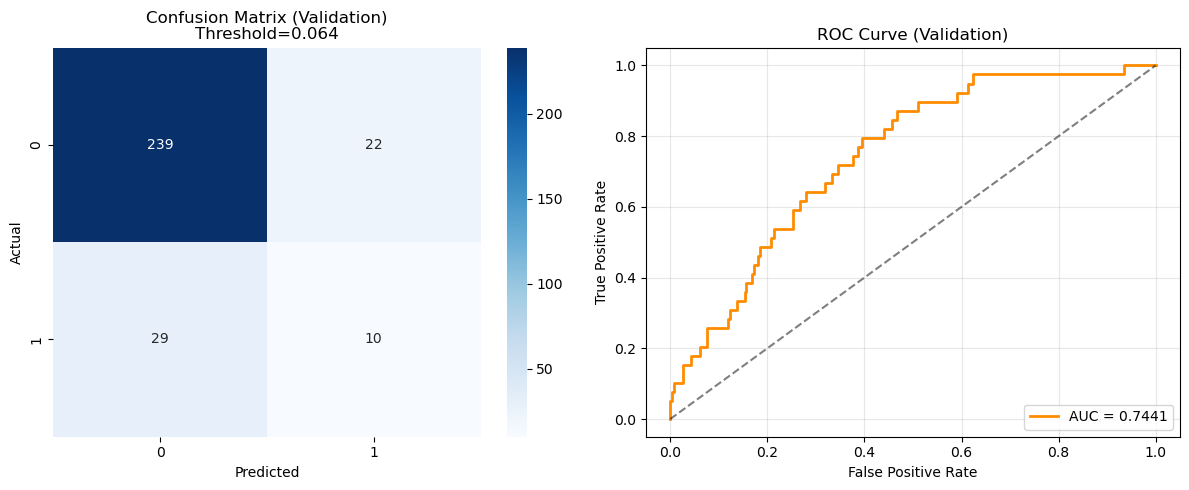

--- Analiza dla progu odcięcia: 0.0640 ---


,PD %,Rating,Status,Threshold,% over threshold
0,2.21%,A,SAFE,6.40%,-4.19%
1,8.44%,CCC,HIGH RISK,6.40%,2.04%
2,1.02%,AA,SAFE,6.40%,-5.38%
3,2.55%,A,SAFE,6.40%,-3.85%
4,9.05%,CCC,HIGH RISK,6.40%,2.65%
5,0.99%,AA,SAFE,6.40%,-5.41%
6,2.31%,A,SAFE,6.40%,-4.09%
7,6.09%,BB,WARNING,6.40%,-0.3%
8,2.27%,A,SAFE,6.40%,-4.12%
9,2.58%,A,SAFE,6.40%,-3.82%


####################
Skalibrowany XGBoost
##############################
Ewaluacja modelu: Skalibrowany XGBoost
Zbiór danych: Validation
Użyty próg (threshold): 0.05971362441778183
##############################

=== Metryki Klasyfikacji (Validation) ===


,precision,recall,f1-score,support
0,0.898785,0.850575,0.874016,261.000000
1,0.264151,0.358974,0.304348,39.000000
accuracy,0.786667,0.786667,0.786667,0.786667
macro avg,0.581468,0.604775,0.589182,300.000000
weighted avg,0.816283,0.786667,0.799959,300.000000



=== Metryki Globalne Probabilistyczne ===


,Validation
ROC AUC,0.7113
PR AUC,0.3161
KS Stat,0.3522
Log Loss,0.4425
Brier Score,0.1175
Accuracy,0.7867


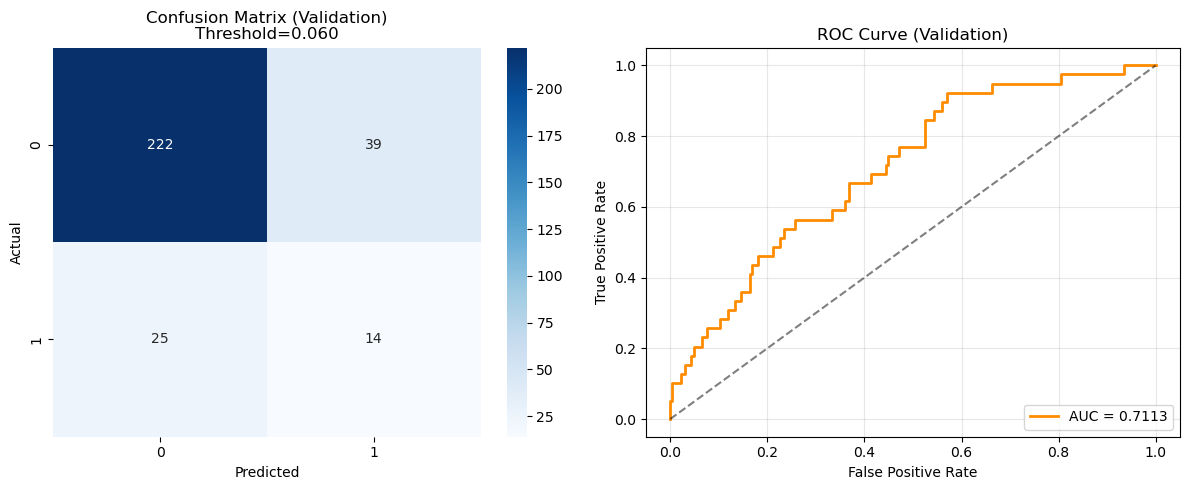

--- Analiza dla progu odcięcia: 0.0597 ---


,PD %,Rating,Status,Threshold,% over threshold
0,0.9%,AA,SAFE,5.97%,-5.07%
1,3.88%,BBB,SAFE,5.97%,-2.09%
2,0.96%,AA,SAFE,5.97%,-5.01%
3,0.81%,AA,SAFE,5.97%,-5.16%
4,3.76%,BBB,SAFE,5.97%,-2.21%
5,0.81%,AA,SAFE,5.97%,-5.16%
6,2.07%,A,SAFE,5.97%,-3.9%
7,3.31%,BBB,SAFE,5.97%,-2.66%
8,1.24%,AA,SAFE,5.97%,-4.73%
9,1.82%,A,SAFE,5.97%,-4.15%


In [5]:
calibrated_LR = processing_predictingPipeline('LR')
calibrated_XGB = processing_predictingPipeline('XGB')
models = [calibrated_LR, calibrated_XGB]
names = ["Skalibrowana Regresja Logistyczna", 'Skalibrowany XGBoost']
short_name = ['CLR', 'CXGB']
with open(r'models/raitings.pkl', 'rb') as f:
    raitings = pickle.load(f)
labels = raitings["labels"]
with open(r'models/thresholds.pkl', 'rb') as f:
    thresholds = pickle.load(f)
for model, name, short_name in zip(models, names, short_name):
    print('#'*20)
    print(name)
    evaluate_model_single_set(model, name, X_val, y_val, threshold=thresholds[short_name], dataset_name='Validation')

    current_binary_thresh = thresholds[short_name]
    current_rating_thresh = raitings[short_name] 

    styled_results = analyze_observations(
        model=model, 
        X_data=X_val, 
        binary_threshold=current_binary_thresh, 
        rating_thresholds=current_rating_thresh, 
        rating_labels=labels,
        n_rows=15 # Pokaż tylko 10 przykładowych klientów
    )
    
    try:
        from IPython.display import display
        display(styled_results)
    except ImportError:
        print(styled_results.data)